<a href="https://colab.research.google.com/github/GHseyram/Ghana-energy-transition-investment-analytics/blob/main/notebooks/python/02_energy_data_analysis.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Ghana Energy Transition Investment Analytics

## Electricity Consumption, Installed Capacity and Industrial Demand

**Author:** Seyram Amedede  
**Data year:** 2025  
**Primary source:** Ghana Energy Commission, 2026 National Energy Statistical Bulletin

### Notebook Purpose

This notebook extends the introductory Python analysis by examining Ghana’s electricity consumption and installed generation capacity. It connects energy-sector data with questions about industrial productivity, solar investment and energy efficiency.

### Research Questions

1. How much electricity did Ghana consume in 2025?
2. What shares were consumed by industry, households and services?
3. How was Ghana’s installed generation capacity distributed?
4. What do these patterns suggest for solar-power and industrial energy-efficiency investment?

### Planned Outputs

- Electricity-consumption summary table
- Sector consumption-share calculations
- Electricity-consumption chart
- Installed-capacity chart
- Preliminary investment interpretation

In [1]:
import pandas as pd
import matplotlib.pyplot as plt

data_url = "https://raw.githubusercontent.com/GHseyram/Ghana-energy-transition-investment-analytics/main/data/ghana-energy-baseline-2025.csv"

energy_data = pd.read_csv(data_url)

print("Dataset loaded successfully.")
print("Number of indicators:", len(energy_data))

energy_data.head()

Dataset loaded successfully.
Number of indicators: 18


,indicator,year,value,unit,category,source_id,source_location
0,Population electricity access rate,2025,89.13,percent,Energy access,S01,Section 1
1,Household electricity access rate,2025,87.99,percent,Energy access,S01,Section 1
2,Total energy supply,2025,15449.00,ktoe,Energy supply,S01,Table 2.1
3,Total final energy consumption,2025,10551.00,ktoe,Energy consumption,S01,Table 2.2
4,Total installed generation capacity,2025,5840.00,MW,Power capacity,S01,Section 3.1


In [2]:
consumption_data = energy_data[
    (energy_data["unit"] == "GWh")
    & energy_data["indicator"].str.contains(
        "consumption",
        case=False,
        na=False
    )
].copy()

consumption_data[["indicator", "value", "unit"]]

,indicator,value,unit
14,Total electricity consumption,21822.0,GWh
15,Industrial electricity consumption,8636.0,GWh
16,Residential electricity consumption,8713.0,GWh
17,Service-sector electricity consumption,4445.0,GWh


In [3]:
total_consumption = consumption_data.loc[
    consumption_data["indicator"] == "Total electricity consumption",
    "value"
].iloc[0]

sector_consumption = consumption_data[
    consumption_data["indicator"] != "Total electricity consumption"
].copy()

sector_consumption["share_percent"] = (
    sector_consumption["value"] / total_consumption * 100
).round(2)

sector_consumption[
    ["indicator", "value", "unit", "share_percent"]
]

,indicator,value,unit,share_percent
15,Industrial electricity consumption,8636.0,GWh,39.57
16,Residential electricity consumption,8713.0,GWh,39.93
17,Service-sector electricity consumption,4445.0,GWh,20.37


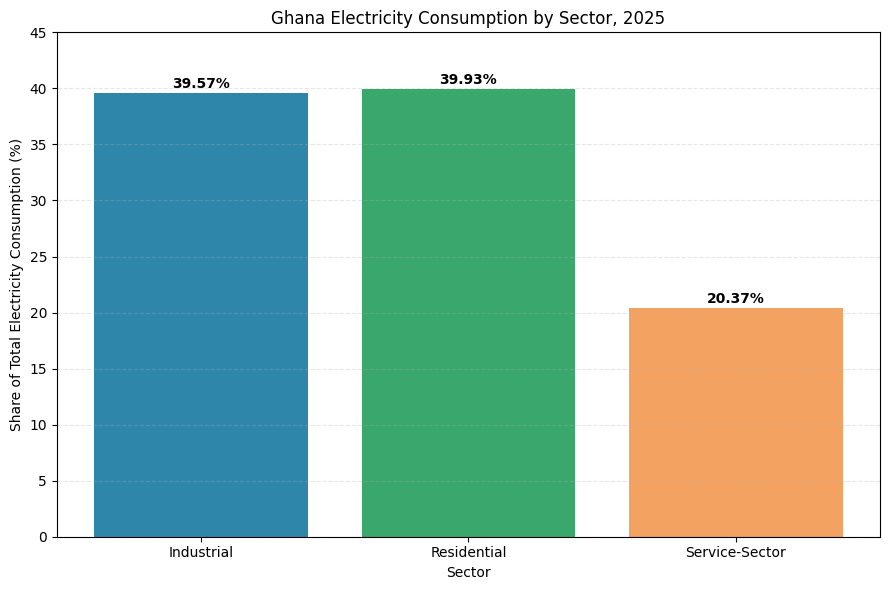

In [4]:
sector_consumption["sector"] = (
    sector_consumption["indicator"]
    .str.replace(" electricity consumption", "", regex=False)
    .str.title()
)

plt.figure(figsize=(9, 6))

bars = plt.bar(
    sector_consumption["sector"],
    sector_consumption["share_percent"],
    color=["#2E86AB", "#3AA76D", "#F4A261"]
)

for bar, share in zip(bars, sector_consumption["share_percent"]):
    plt.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height() + 0.5,
        f"{share:.2f}%",
        ha="center",
        fontweight="bold"
    )

plt.title("Ghana Electricity Consumption by Sector, 2025")
plt.xlabel("Sector")
plt.ylabel("Share of Total Electricity Consumption (%)")
plt.ylim(0, 45)
plt.grid(axis="y", linestyle="--", alpha=0.3)
plt.tight_layout()
plt.show()

## Interpretation

In 2025, Ghana’s residential sector accounted for approximately **39.93%** of total electricity consumption, while industry represented **39.57%** and the service sector represented **20.37%**.

The substantial industrial share indicates that electricity availability, reliability and cost are important factors affecting Ghana’s industrial productivity and competitiveness. It also suggests potential demand for investments in commercial and industrial solar systems, energy-efficient machinery, cooling systems and energy-management technologies.

Residential demand was marginally higher than industrial demand, demonstrating the importance of household electricity access and distributed-energy solutions. However, these consumption shares alone do not measure energy efficiency or determine whether a particular investment is financially viable. Further analysis of tariffs, consumption patterns, technology costs and potential energy savings is required.

In [5]:
capacity_data = energy_data[
    (energy_data["unit"] == "MW")
    & energy_data["indicator"].str.contains(
        "capacity",
        case=False,
        na=False
    )
].copy()

capacity_data[["indicator", "value", "unit"]]


,indicator,value,unit
4,Total installed generation capacity,5840.0,MW
5,Hydro installed capacity,1584.0,MW
6,Thermal installed capacity,4073.0,MW
7,Other renewable installed capacity,183.0,MW


In [6]:
total_capacity = capacity_data.loc[
    capacity_data["indicator"] == "Total installed generation capacity",
    "value"
].iloc[0]

technology_capacity = capacity_data[
    capacity_data["indicator"] != "Total installed generation capacity"
].copy()

technology_capacity["share_percent"] = (
    technology_capacity["value"] / total_capacity * 100
).round(2)

technology_capacity[
    ["indicator", "value", "unit", "share_percent"]
]

,indicator,value,unit,share_percent
5,Hydro installed capacity,1584.0,MW,27.12
6,Thermal installed capacity,4073.0,MW,69.74
7,Other renewable installed capacity,183.0,MW,3.13


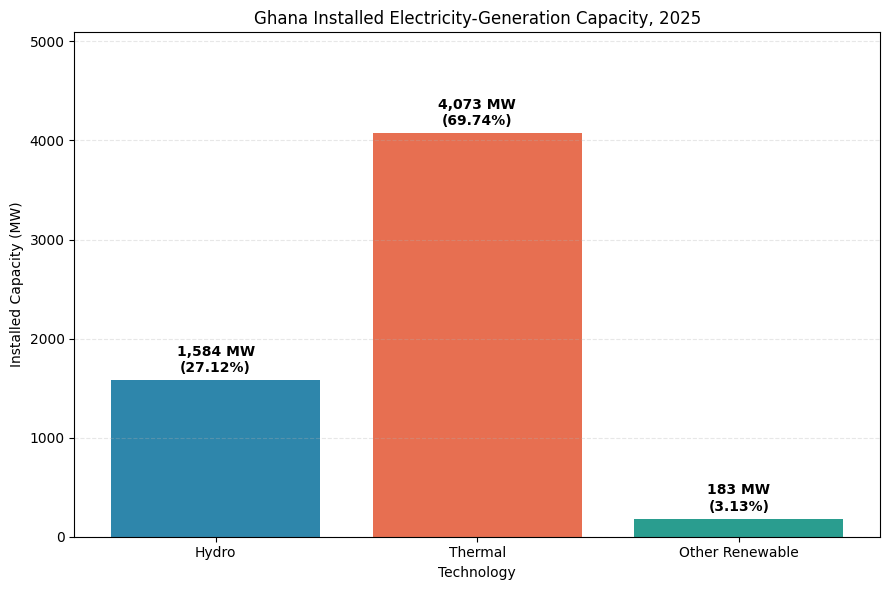

In [7]:
technology_capacity["technology"] = (
    technology_capacity["indicator"]
    .str.replace(" installed capacity", "", regex=False)
    .str.title()
)

plt.figure(figsize=(9, 6))

bars = plt.bar(
    technology_capacity["technology"],
    technology_capacity["value"],
    color=["#2E86AB", "#E76F51", "#2A9D8F"]
)

for bar, capacity, share in zip(
    bars,
    technology_capacity["value"],
    technology_capacity["share_percent"]
):
    plt.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height() + 80,
        f"{capacity:,.0f} MW\n({share:.2f}%)",
        ha="center",
        fontweight="bold"
    )

plt.title("Ghana Installed Electricity-Generation Capacity, 2025")
plt.xlabel("Technology")
plt.ylabel("Installed Capacity (MW)")
plt.ylim(0, technology_capacity["value"].max() * 1.25)
plt.grid(axis="y", linestyle="--", alpha=0.3)
plt.tight_layout()
plt.show()

## Investment Interpretation

Ghana had approximately **5,840 MW** of installed electricity-generation capacity in 2025. Thermal power accounted for **69.74%**, hydroelectric power represented **27.12%**, and other renewable technologies accounted for only **3.13%**.

The dominance of thermal capacity indicates exposure to fuel prices, foreign-exchange movements and fuel-supply risks. Expanding solar power, battery storage and other renewable technologies could help diversify the generation system and reduce some of these risks.

The relatively small share of other renewables suggests considerable room for market growth. However, a low existing share does not automatically make every renewable-energy project financially viable. Investment decisions must also consider tariffs, financing costs, grid connections, power-purchase arrangements and customer demand.

Installed capacity measures the maximum potential output of power facilities. It is different from actual electricity generated because plant availability, fuel supply, weather conditions, maintenance and dispatch decisions affect production.

In [8]:
system_peak = energy_data.loc[
    energy_data["indicator"].str.contains(
        "system peak",
        case=False,
        na=False
    ),
    "value"
].iloc[0]

nominal_capacity_margin_mw = total_capacity - system_peak

nominal_capacity_margin_percent = (
    nominal_capacity_margin_mw / system_peak * 100
)

print("Total installed capacity:", f"{total_capacity:,.0f} MW")
print("System peak demand:", f"{system_peak:,.0f} MW")
print(
    "Nominal capacity margin:",
    f"{nominal_capacity_margin_mw:,.0f} MW"
)
print(
    "Nominal margin relative to peak:",
    f"{nominal_capacity_margin_percent:.2f}%"
)

Total installed capacity: 5,840 MW
System peak demand: 4,283 MW
Nominal capacity margin: 1,557 MW
Nominal margin relative to peak: 36.35%


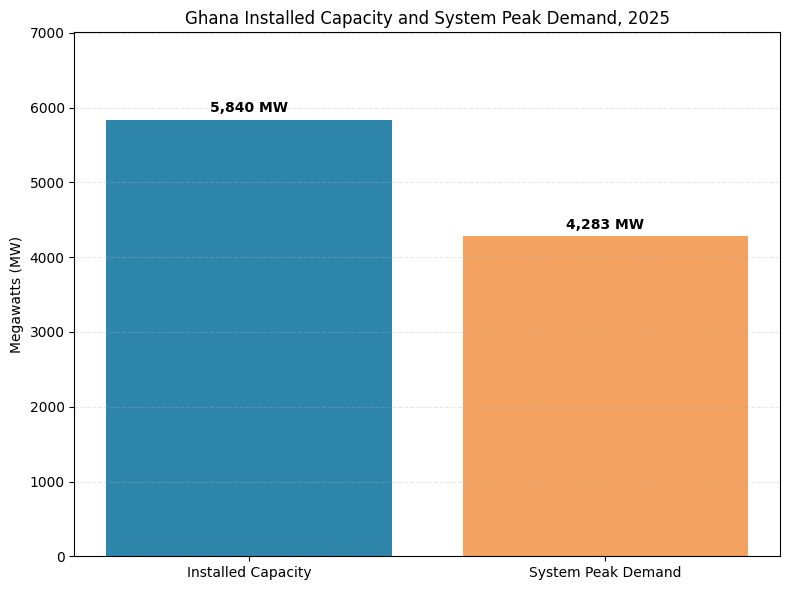

In [9]:
comparison_labels = [
    "Installed Capacity",
    "System Peak Demand"
]

comparison_values = [
    total_capacity,
    system_peak
]

plt.figure(figsize=(8, 6))

bars = plt.bar(
    comparison_labels,
    comparison_values,
    color=["#2E86AB", "#F4A261"]
)

for bar, value in zip(bars, comparison_values):
    plt.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height() + 100,
        f"{value:,.0f} MW",
        ha="center",
        fontweight="bold"
    )

plt.title("Ghana Installed Capacity and System Peak Demand, 2025")
plt.ylabel("Megawatts (MW)")
plt.ylim(0, max(comparison_values) * 1.2)
plt.grid(axis="y", linestyle="--", alpha=0.3)
plt.tight_layout()
plt.show()

## Capacity Adequacy Interpretation

Ghana’s installed generation capacity exceeded the 2025 system peak demand by approximately **1,557 MW**, equivalent to a nominal margin of **36.35%** relative to peak demand.

This comparison does not prove that all electricity demand can always be met reliably. Installed capacity includes plants that may be unavailable because of maintenance, fuel constraints, technical problems, hydrological conditions or variable renewable-energy output. Transmission and distribution limitations can also affect electricity delivery.

The investment challenge is therefore broader than simply adding more generation capacity. Potential opportunities include reliable solar-plus-storage systems, grid improvements, flexible generation, industrial energy-efficiency investments and demand-management technologies.

A complete capacity-adequacy assessment would require data on dependable capacity, plant outages, hourly demand, fuel availability and operating reserves.
